# pypdf + python-docx Performance Benchmarks

**Purpose:** Evaluate whether `pypdf` + `python-docx` can convert 60-page PDFs within the 90-second Celery task timeout, as an alternative to `pdf2docx`.

**Libraries:**
- [pypdf](https://github.com/py-pdf/pypdf) — Pure-Python PDF reader (text extraction, image extraction, metadata)
- [python-docx](https://github.com/python-openxml/python-docx) — DOCX generation via Open XML
- [PyMuPDF/fitz](https://github.com/pymupdf/PyMuPDF) — Used only to generate test PDFs (same as pdf2docx benchmark)

**Conversion pipeline stages:**
1. Open PDF with `pypdf.PdfReader`
2. Extract text per page (`.extract_text()`)
3. Extract images per page (`.images`)
4. Build DOCX with `python-docx` (paragraphs, images, basic formatting)

**Key limitations vs pdf2docx:**
- No table detection — tables come through as plain text lines
- No layout preservation — text is extracted in reading order, but spatial positioning is lost
- No font/style mapping — all text uses default DOCX styles
- Images are extracted but not positioned relative to surrounding text

---

In [1]:
import fitz  # PyMuPDF — only for generating test PDFs
import io
import logging
import os
import struct
import time
import zlib

import pypdf
from docx import Document
from docx.shared import Inches, Pt
from docx.enum.text import WD_ALIGN_PARAGRAPH

PAGES = 60
OUTPUT_DIR = "/tmp/pypdf_docx_bench"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Collect results for the final summary
results = []


def convert_pdf_to_docx(pdf_path, docx_path, extract_images=True):
    """Convert a PDF to DOCX using pypdf + python-docx.
    
    Pipeline:
    1. Read PDF with pypdf
    2. For each page: extract text and (optionally) images
    3. Write content into a python-docx Document
    """
    reader = pypdf.PdfReader(pdf_path)
    doc = Document()
    
    for page_num, page in enumerate(reader.pages):
        # Add page heading
        if page_num > 0:
            doc.add_page_break()
        
        # Extract and add text
        text = page.extract_text() or ""
        for line in text.split("\n"):
            line = line.strip()
            if line:
                doc.add_paragraph(line)
        
        # Extract and add images
        if extract_images:
            try:
                for img_idx, image in enumerate(page.images):
                    img_stream = io.BytesIO(image.data)
                    try:
                        doc.add_picture(img_stream, width=Inches(3))
                    except Exception:
                        # Some image formats may not be supported by python-docx
                        pass
            except Exception:
                pass
    
    doc.save(docx_path)


def run_conversion(name, pdf_path, docx_path, extract_images=True):
    """Convert a PDF to DOCX and record timing."""
    pdf_kb = os.path.getsize(pdf_path) / 1024
    start = time.time()
    convert_pdf_to_docx(pdf_path, docx_path, extract_images=extract_images)
    elapsed = time.time() - start
    docx_kb = os.path.getsize(docx_path) / 1024
    per_page = elapsed / PAGES
    verdict = "Safe" if elapsed < 60 else ("At risk" if elapsed < 90 else "Exceeds 90s")
    results.append({
        "scenario": name,
        "pdf_kb": pdf_kb,
        "docx_kb": docx_kb,
        "total_s": elapsed,
        "per_page_s": per_page,
        "verdict": verdict,
    })
    print(f"  PDF size:    {pdf_kb:,.0f} KB")
    print(f"  DOCX size:   {docx_kb:,.0f} KB")
    print(f"  Total time:  {elapsed:.2f}s")
    print(f"  Per page:    {per_page:.3f}s")
    print(f"  Verdict:     {verdict}")
    return elapsed


print(f"pypdf version:      {pypdf.__version__}")
print(f"python-docx:        available")
print(f"PyMuPDF version:    {fitz.version} (test PDF generation only)")
print(f"Generating {PAGES}-page test PDFs in {OUTPUT_DIR}/")

pypdf version:      6.4.0
python-docx:        available
PyMuPDF version:    ('1.24.3', '1.24.2', '20240509000001') (test PDF generation only)
Generating 60-page test PDFs in /tmp/pypdf_docx_bench/


---
## Scenario 1: Text-Only

60 pages of plain text. Each page has a heading and 25 lines of lorem ipsum body text at 10pt.

This is the **best case** — no tables, no images, just text extraction and paragraph creation.

pypdf's `extract_text()` uses a pure-Python text extraction engine. python-docx paragraph creation is fast.

In [2]:
pdf_path = os.path.join(OUTPUT_DIR, "test_text_only.pdf")
docx_path = os.path.join(OUTPUT_DIR, "out_text_only.docx")

# --- Generate PDF (same as pdf2docx benchmark) ---
doc = fitz.open()
for i in range(PAGES):
    page = doc.new_page(width=612, height=792)  # US Letter
    page.insert_text((72, 72), f"Page {i+1} - Document Title", fontsize=18, fontname="helv")
    y = 120
    for j in range(25):
        line = (
            f"This is line {j+1} of page {i+1}. Lorem ipsum dolor sit amet, "
            "consectetur adipiscing elit. Sed do eiusmod tempor incididunt ut "
            "labore et dolore magna aliqua. Ut enim ad minim veniam."
        )
        page.insert_text((72, y), line[:90], fontsize=10, fontname="helv")
        y += 20
doc.save(pdf_path)
doc.close()

# --- Convert & Benchmark ---
print("Scenario 1: Text-Only (25 lines/page)")
print("=" * 40)
run_conversion("Text-only", pdf_path, docx_path, extract_images=False)

Scenario 1: Text-Only (25 lines/page)
  PDF size:    398 KB
  DOCX size:   40 KB
  Total time:  0.19s
  Per page:    0.003s
  Verdict:     Safe


0.18883395195007324

---
## Scenario 2: Text + Simple Tables

60 pages with a heading, 8 text paragraphs, one **5x4 table** with cell data, and 8 more text paragraphs below.

**Important:** pypdf has no table detection. The table cell text will be extracted as plain text lines. This means the output DOCX will NOT contain actual tables — just text. The benchmark here is purely about speed, not fidelity.

In [3]:
pdf_path = os.path.join(OUTPUT_DIR, "test_simple_tables.pdf")
docx_path = os.path.join(OUTPUT_DIR, "out_simple_tables.docx")

# --- Generate PDF (same as pdf2docx benchmark) ---
doc = fitz.open()
for i in range(PAGES):
    page = doc.new_page(width=612, height=792)
    page.insert_text((72, 60), f"Section {i+1}: Analysis Report", fontsize=16, fontname="helv")
    y = 100
    for j in range(8):
        text = (
            f"Paragraph {j+1}: The quick brown fox jumps over the lazy dog. "
            "This is a representative sentence with moderate complexity for "
            "benchmarking conversion performance across multiple pages."
        )
        page.insert_text((72, y), text[:95], fontsize=10, fontname="helv")
        y += 18
    # Draw a 5-row x 4-column table
    table_y = y + 10
    for row in range(5):
        for col in range(4):
            x0 = 72 + col * 115
            y0 = table_y + row * 25
            rect = fitz.Rect(x0, y0, x0 + 115, y0 + 25)
            page.draw_rect(rect, color=(0, 0, 0), width=0.5)
            page.insert_text(
                (x0 + 5, y0 + 17), f"Cell {row},{col}: data", fontsize=8, fontname="helv"
            )
    y = table_y + 150
    for j in range(8):
        text = (
            f"Additional content line {j+1}: Further analysis shows that the "
            "data points correlate with the observed trends in the baseline "
            "measurements taken during the study period."
        )
        page.insert_text((72, y), text[:95], fontsize=10, fontname="helv")
        y += 18
doc.save(pdf_path)
doc.close()

# --- Convert & Benchmark ---
print("Scenario 2: Text + Simple Tables (1 table/page, 5x4)")
print("=" * 50)
run_conversion("Text + simple tables", pdf_path, docx_path, extract_images=False)

Scenario 2: Text + Simple Tables (1 table/page, 5x4)
  PDF size:    593 KB
  DOCX size:   37 KB
  Total time:  0.19s
  Per page:    0.003s
  Verdict:     Safe


0.1867687702178955

---
## Scenario 3: Dense Tables — Worst Case

60 pages, each containing **3 tables** (8 rows x 6 columns each).  
That's **180 tables / 8,640 total cells** across the document.

This was the **primary bottleneck for pdf2docx** (92s, exceeding the 90s timeout) due to O(n^2) table detection.

pypdf doesn't do table detection at all — it just extracts text. So this scenario should be fast but with **zero table structure preservation**.

In [4]:
pdf_path = os.path.join(OUTPUT_DIR, "test_dense_tables.pdf")
docx_path = os.path.join(OUTPUT_DIR, "out_dense_tables.docx")

# --- Generate PDF (same as pdf2docx benchmark) ---
doc = fitz.open()
for i in range(PAGES):
    page = doc.new_page(width=612, height=792)
    page.insert_text(
        (72, 50), f"SECTION {i+1}: FINANCIAL ANALYSIS REPORT", fontsize=14, fontname="helv"
    )
    page.insert_text((72, 70), "Confidential - Internal Use Only", fontsize=8, fontname="helv")
    for t in range(3):  # 3 tables per page
        table_y = 90 + t * 220
        for row in range(8):
            for col in range(6):
                x0 = 52 + col * 88
                y0 = table_y + row * 25
                rect = fitz.Rect(x0, y0, x0 + 88, y0 + 25)
                page.draw_rect(rect, color=(0, 0, 0), width=0.5)
                if row == 0:
                    page.insert_text(
                        (x0 + 3, y0 + 17), f"Header {col+1}", fontsize=7, fontname="helv"
                    )
                else:
                    page.insert_text(
                        (x0 + 3, y0 + 17),
                        f"{(i * 1000 + row * 100 + col * 10):,.2f}",
                        fontsize=7,
                        fontname="helv",
                    )
doc.save(pdf_path)
doc.close()

# --- Convert & Benchmark ---
print("Scenario 3: Dense Tables — Worst Case (3 tables/page, 8x6 each)")
print("=" * 60)
print(f"  Total tables: {PAGES * 3}")
print(f"  Total cells:  {PAGES * 3 * 8 * 6:,}")
print(f"  NOTE: pypdf extracts table text as flat lines (no table structure)")
print()
run_conversion("Dense tables (worst case)", pdf_path, docx_path, extract_images=False)

Scenario 3: Dense Tables — Worst Case (3 tables/page, 8x6 each)
  Total tables: 180
  Total cells:  8,640
  NOTE: pypdf extracts table text as flat lines (no table structure)



  PDF size:    2,301 KB
  DOCX size:   44 KB
  Total time:  0.64s
  Per page:    0.011s
  Verdict:     Safe


0.6434822082519531

---
## Scenario 4: Mixed Content (Text + Images + Tables)

60 pages, each containing a heading, 5 text paragraphs, an **embedded 200x150 PNG image**, a **6x5 table**, and 6 closing paragraphs.

**Most representative of a typical contract/business document.**

pypdf can extract embedded images via `page.images`. python-docx can insert them into the DOCX. This tests the full extraction + generation pipeline.

In [5]:
pdf_path = os.path.join(OUTPUT_DIR, "test_mixed_content.pdf")
docx_path = os.path.join(OUTPUT_DIR, "out_mixed_content.docx")


def create_png(width, height, r, g, b):
    """Create a minimal RGB PNG image in memory."""
    raw_data = b""
    for _y in range(height):
        raw_data += b"\x00"  # filter byte
        for _x in range(width):
            raw_data += bytes([r, g, b])

    def chunk(chunk_type, data):
        c = chunk_type + data
        crc = zlib.crc32(c) & 0xFFFFFFFF
        return struct.pack(">I", len(data)) + c + struct.pack(">I", crc)

    ihdr = struct.pack(">IIBBBBB", width, height, 8, 2, 0, 0, 0)
    png = b"\x89PNG\r\n\x1a\n"
    png += chunk(b"IHDR", ihdr)
    png += chunk(b"IDAT", zlib.compress(raw_data))
    png += chunk(b"IEND", b"")
    return png


img_bytes = create_png(200, 150, 100, 150, 200)

# --- Generate PDF (same as pdf2docx benchmark) ---
doc = fitz.open()
for i in range(PAGES):
    page = doc.new_page(width=612, height=792)
    page.insert_text((72, 50), f"Document Section {i+1}", fontsize=16, fontname="helv")
    y = 80
    for j in range(5):
        page.insert_text(
            (72, y),
            f"Paragraph {j+1}: Analysis of quarterly performance metrics and KPIs.",
            fontsize=10,
            fontname="helv",
        )
        y += 16
    # Embedded image
    img_rect = fitz.Rect(72, y + 10, 272, y + 160)
    page.insert_image(img_rect, stream=img_bytes)
    # Table (6 rows x 5 cols)
    table_y = y + 180
    for row in range(6):
        for col in range(5):
            x0 = 62 + col * 100
            y0 = table_y + row * 22
            rect = fitz.Rect(x0, y0, x0 + 100, y0 + 22)
            page.draw_rect(rect, color=(0, 0, 0), width=0.5)
            page.insert_text((x0 + 3, y0 + 15), f"Val {row}{col}", fontsize=7, fontname="helv")
    y2 = table_y + 160
    for j in range(6):
        page.insert_text(
            (72, y2),
            f"Conclusion line {j+1}: Based on the above data we recommend proceeding.",
            fontsize=10,
            fontname="helv",
        )
        y2 += 16
doc.save(pdf_path)
doc.close()

# --- Convert & Benchmark ---
print("Scenario 4: Mixed Content (text + images + tables)")
print("=" * 50)
run_conversion("Mixed content", pdf_path, docx_path, extract_images=True)

Scenario 4: Mixed Content (text + images + tables)


  PDF size:    730 KB
  DOCX size:   38 KB
  Total time:  0.36s
  Per page:    0.006s
  Verdict:     Safe


0.35909581184387207

---
## Scenario 5: Image-Heavy Document

60 pages, each with a heading, 3 text lines, and **3 embedded PNG images** of varying sizes.

Tests the image extraction pipeline — `pypdf` must decode each image from the PDF's internal format, and `python-docx` must re-encode and embed it in the DOCX.

This scenario does not exist in the pdf2docx benchmark. Added here because image extraction is a distinct bottleneck for pypdf (pure Python decoding vs. pdf2docx's C-based PyMuPDF).

In [6]:
pdf_path = os.path.join(OUTPUT_DIR, "test_image_heavy.pdf")
docx_path = os.path.join(OUTPUT_DIR, "out_image_heavy.docx")

# Create images of different sizes
img_small = create_png(100, 75, 200, 100, 100)    # small
img_medium = create_png(300, 225, 100, 200, 100)   # medium
img_large = create_png(500, 375, 100, 100, 200)    # large

# --- Generate PDF ---
doc = fitz.open()
for i in range(PAGES):
    page = doc.new_page(width=612, height=792)
    page.insert_text((72, 50), f"Image Gallery - Page {i+1}", fontsize=16, fontname="helv")
    page.insert_text((72, 75), "This page contains multiple embedded images.", fontsize=10, fontname="helv")
    page.insert_text((72, 90), "Testing image extraction and reinsertion performance.", fontsize=10, fontname="helv")
    page.insert_text((72, 105), f"Image set {i+1} of {PAGES}.", fontsize=10, fontname="helv")
    
    # 3 images per page
    page.insert_image(fitz.Rect(72, 130, 172, 205), stream=img_small)
    page.insert_image(fitz.Rect(72, 220, 372, 445), stream=img_medium)
    page.insert_image(fitz.Rect(72, 460, 572, 760), stream=img_large)
doc.save(pdf_path)
doc.close()

print(f"Total images: {PAGES * 3}")
print(f"Image sizes: small (100x75), medium (300x225), large (500x375)")
print()

# --- Convert & Benchmark ---
print("Scenario 5: Image-Heavy (3 images/page)")
print("=" * 45)
run_conversion("Image-heavy", pdf_path, docx_path, extract_images=True)

# Also test without image extraction for comparison
docx_path_noimg = os.path.join(OUTPUT_DIR, "out_image_heavy_noimg.docx")
print()
print("--- Same PDF, images SKIPPED ---")
run_conversion("Image-heavy (no img extract)", pdf_path, docx_path_noimg, extract_images=False)

Total images: 180
Image sizes: small (100x75), medium (300x225), large (500x375)

Scenario 5: Image-Heavy (3 images/page)


  PDF size:    851 KB
  DOCX size:   39 KB
  Total time:  0.49s
  Per page:    0.008s
  Verdict:     Safe

--- Same PDF, images SKIPPED ---
  PDF size:    851 KB
  DOCX size:   36 KB
  Total time:  0.04s
  Per page:    0.001s
  Verdict:     Safe


0.03504681587219238

---
## Scenario 6: Two-Column Layout (MSA-style)

60 pages of **two-column text** with section headings — the layout commonly found in Master Service Agreements, legal contracts, and insurance documents.

Tests pypdf's text extraction reading order for multi-column layouts. pypdf extracts text in the order it appears in the PDF content stream, which may not match visual reading order for multi-column documents.

In [7]:
from reportlab.platypus import BaseDocTemplate, Frame, PageTemplate, Paragraph as RLParagraph, Spacer as RLSpacer
from reportlab.lib.pagesizes import letter as rl_letter
from reportlab.lib.units import inch as rl_inch
from reportlab.lib.styles import getSampleStyleSheet as rlGetStyles, ParagraphStyle
from reportlab.lib.enums import TA_JUSTIFY

pdf_path = os.path.join(OUTPUT_DIR, "test_two_column_msa.pdf")
docx_path = os.path.join(OUTPUT_DIR, "out_two_column_msa.docx")

msa_sections = [
    ("1. DEFINITIONS", [
        '"Agreement" means this Master Service Agreement, including all exhibits and schedules attached hereto.',
        '"Confidential Information" means any information disclosed by one party to the other party, either directly or indirectly, in writing, orally, or by inspection of tangible objects.',
        '"Effective Date" means the date first written above or the date of the last signature below, whichever is later.',
        '"Intellectual Property" means all patents, copyrights, trademarks, trade secrets, and other proprietary rights.',
        '"Services" means the professional services to be provided by Service Provider as described in each Statement of Work.',
        '"Term" means the period commencing on the Effective Date and continuing until terminated in accordance with Section 8.',
    ]),
    ("2. SCOPE OF SERVICES", [
        "Service Provider shall perform the Services described in each Statement of Work executed by both parties.",
        "Each Statement of Work shall describe the scope, timeline, deliverables, fees, and payment terms.",
        "Service Provider shall assign qualified personnel with appropriate skills and experience to perform the Services.",
        "Client may request changes to the Services by submitting a written change order to Service Provider.",
        "Service Provider shall use commercially reasonable efforts to accommodate such change requests.",
    ]),
    ("3. COMPENSATION AND PAYMENT", [
        "Client shall pay Service Provider the fees set forth in each Statement of Work.",
        "Unless otherwise specified, all invoices shall be due and payable within thirty (30) days of receipt.",
        "Late payments shall accrue interest at the rate of one and one-half percent (1.5%) per month.",
        "Service Provider shall submit itemized invoices on a monthly basis detailing the Services performed.",
        "Client shall reimburse Service Provider for reasonable travel and out-of-pocket expenses pre-approved in writing.",
        "All fees are exclusive of applicable taxes, which shall be the responsibility of Client.",
    ]),
    ("4. CONFIDENTIALITY", [
        "Each party agrees to maintain the confidentiality of all Confidential Information received from the other party.",
        "Neither party shall disclose Confidential Information to any third party without prior written consent.",
        "The obligations of confidentiality shall not apply to information that: (a) is or becomes publicly available through no fault of the receiving party; (b) was already known to the receiving party prior to disclosure; (c) is independently developed by the receiving party without use of the Confidential Information; or (d) is required to be disclosed by law or court order.",
        "Upon termination, each party shall return or destroy all Confidential Information in its possession.",
        "The obligations under this Section shall survive termination of this Agreement for a period of five (5) years.",
    ]),
    ("5. INTELLECTUAL PROPERTY", [
        "All pre-existing Intellectual Property shall remain the property of the party that owned it prior to the engagement.",
        "Work product created by Service Provider specifically for Client shall be owned by Client upon full payment.",
        "Service Provider retains the right to use general knowledge, skills, and experience gained during the engagement.",
        "Client grants Service Provider a limited license to use Client materials solely for performing the Services.",
    ]),
    ("6. WARRANTIES AND REPRESENTATIONS", [
        "Service Provider warrants that the Services will be performed in a professional and workmanlike manner.",
        "Service Provider represents that it has the authority to enter into this Agreement and perform the Services.",
        "EXCEPT AS EXPRESSLY SET FORTH HEREIN, NEITHER PARTY MAKES ANY WARRANTIES, EXPRESS OR IMPLIED, INCLUDING BUT NOT LIMITED TO WARRANTIES OF MERCHANTABILITY OR FITNESS FOR A PARTICULAR PURPOSE.",
        "Client warrants that it has the right to provide all materials and information necessary for the Services.",
    ]),
    ("7. LIMITATION OF LIABILITY", [
        "IN NO EVENT SHALL EITHER PARTY BE LIABLE FOR ANY INDIRECT, INCIDENTAL, SPECIAL, CONSEQUENTIAL, OR PUNITIVE DAMAGES.",
        "THE TOTAL LIABILITY OF EITHER PARTY SHALL NOT EXCEED THE FEES PAID OR PAYABLE UNDER THE APPLICABLE STATEMENT OF WORK.",
        "The limitations set forth in this Section shall apply regardless of the form of action, whether in contract, tort, or otherwise.",
        "Nothing in this Agreement shall limit liability for gross negligence, willful misconduct, or fraud.",
    ]),
    ("8. TERM AND TERMINATION", [
        "This Agreement shall commence on the Effective Date and continue for an initial term of one (1) year.",
        "Either party may terminate this Agreement for convenience upon sixty (60) days prior written notice.",
        "Either party may terminate immediately upon material breach if such breach is not cured within thirty (30) days of notice.",
        "Upon termination, Service Provider shall deliver all completed work product to Client.",
        "Sections 4, 5, 7, and 9 shall survive termination of this Agreement.",
    ]),
    ("9. INDEMNIFICATION", [
        "Each party shall indemnify and hold harmless the other party from any claims, damages, or expenses arising from the indemnifying party's breach of this Agreement.",
        "Service Provider shall indemnify Client against claims that the Services infringe any third-party intellectual property rights.",
        "Client shall indemnify Service Provider against claims arising from Client's use of the deliverables in violation of applicable law.",
        "The indemnified party shall provide prompt written notice of any claim and reasonable cooperation in the defense thereof.",
    ]),
    ("10. GENERAL PROVISIONS", [
        "This Agreement constitutes the entire agreement between the parties and supersedes all prior agreements and understandings.",
        "This Agreement may be amended only by a written instrument signed by both parties.",
        "Neither party may assign this Agreement without the prior written consent of the other party.",
        "This Agreement shall be governed by and construed in accordance with the laws of the State of Delaware.",
        "Any dispute arising under this Agreement shall be resolved through binding arbitration in Wilmington, Delaware.",
        "If any provision of this Agreement is held invalid or unenforceable, the remaining provisions shall remain in full force.",
        "The waiver of any breach shall not constitute a waiver of any subsequent breach.",
        "All notices shall be in writing and delivered to the addresses set forth on the signature page.",
    ]),
]

# Build two-column PDF using reportlab Frames
page_w, page_h = rl_letter
margin = 0.75 * rl_inch
col_gap = 0.3 * rl_inch
col_w = (page_w - 2 * margin - col_gap) / 2

frame_left = Frame(margin, margin, col_w, page_h - 2 * margin, id="left")
frame_right = Frame(margin + col_w + col_gap, margin, col_w, page_h - 2 * margin, id="right")
two_col_template = PageTemplate(id="TwoCol", frames=[frame_left, frame_right])

rl_doc = BaseDocTemplate(pdf_path, pagesize=rl_letter)
rl_doc.addPageTemplates([two_col_template])

rl_styles = rlGetStyles()
heading_style = ParagraphStyle(
    "MSAHeading", parent=rl_styles["Heading3"],
    alignment=TA_JUSTIFY, spaceAfter=6, spaceBefore=12,
    fontSize=10, leading=12, fontName="Helvetica-Bold",
)
body_style = ParagraphStyle(
    "MSABody", parent=rl_styles["Normal"],
    alignment=TA_JUSTIFY, spaceAfter=6, spaceBefore=2,
    fontSize=8.5, leading=11, fontName="Times-Roman",
)

story = []
repeats_needed = max(1, PAGES // 5)
for rep in range(repeats_needed):
    for section_title, paragraphs in msa_sections:
        story.append(RLParagraph(f"<b>{section_title}</b>", heading_style))
        for para_text in paragraphs:
            story.append(RLParagraph(para_text, body_style))
        story.append(RLSpacer(1, 6))

rl_doc.build(story)

with open(pdf_path, "rb") as f:
    content = f.read()
    page_count = content.count(b"/Type /Page") - content.count(b"/Type /Pages")

print("Scenario 6: Two-Column MSA Layout")
print(f"  Generated {page_count} pages")
print("=" * 55)
run_conversion("Two-column MSA", pdf_path, docx_path, extract_images=False)

Scenario 6: Two-Column MSA Layout
  Generated 18 pages


  PDF size:    64 KB
  DOCX size:   40 KB
  Total time:  0.11s
  Per page:    0.002s
  Verdict:     Safe


0.10726809501647949

---
## Scenario: Two-Column MSA with Layout Preservation

The previous scenario used `pypdf`'s `extract_text()` which returns text in reading order but **loses all column structure** — the output DOCX is single-column flowing paragraphs.

This scenario improves on that by using **PyMuPDF's `page.get_text("blocks")`** to get text blocks with their bounding box coordinates `(x0, y0, x1, y1)`. With spatial information we can:

1. **Detect columns** — find the horizontal gap between left and right text block clusters
2. **Split blocks** into left-column and right-column groups based on x-position
3. **Sort each column** by y-coordinate (top to bottom) to restore reading order
4. **Build a two-column DOCX** using Word's `w:cols` section formatting so the output visually matches the original PDF layout

This demonstrates that PyMuPDF's block-level coordinates are sufficient for basic multi-column layout preservation without needing full pdf2docx-style layout analysis.

In [8]:
from docx.oxml.ns import qn
from docx.oxml import OxmlElement
from docx.enum.text import WD_BREAK

# Reuse the two-column MSA PDF from the previous scenario
pdf_path = os.path.join(OUTPUT_DIR, "test_two_column_msa.pdf")
docx_v2_path = os.path.join(OUTPUT_DIR, "two_column_msa_v2.docx")


def detect_column_boundary(blocks):
    """Detect the column boundary by finding the largest horizontal gap between text blocks.
    
    Collects the x0 (left edge) and x1 (right edge) of every text block,
    then looks for the biggest gap in the sorted x-coordinates that sits
    near the middle of the page.  Falls back to page-width midpoint.
    """
    if not blocks:
        return None

    # Collect all x-ranges from text blocks
    x_ranges = [(b[0], b[2]) for b in blocks if b[6] == 0]  # block_type 0 = text
    if len(x_ranges) < 2:
        return None

    # Gather all unique x0 values and sort them
    x0_values = sorted(set(b[0] for b in blocks if b[6] == 0))
    if len(x0_values) < 2:
        return None

    # Find the largest gap between consecutive x0 values
    max_gap = 0
    boundary = None
    for i in range(len(x0_values) - 1):
        gap = x0_values[i + 1] - x0_values[i]
        if gap > max_gap:
            max_gap = gap
            boundary = (x0_values[i] + x0_values[i + 1]) / 2

    # Sanity check: the gap should be meaningful (at least 20 points)
    if boundary is not None and max_gap > 20:
        return boundary

    return None


def set_two_column_layout(section):
    """Configure a DOCX section for two-column layout, replacing any existing w:cols element."""
    sectPr = section._sectPr
    # Remove any existing w:cols elements to avoid duplicates
    for existing_cols in sectPr.findall(qn("w:cols")):
        sectPr.remove(existing_cols)
    # Add new w:cols with 2 columns
    cols = OxmlElement("w:cols")
    cols.set(qn("w:num"), "2")
    cols.set(qn("w:space"), "720")  # gap between columns in twips (0.5 inch)
    sectPr.append(cols)


def convert_two_column_pdf_to_docx(pdf_path, docx_path):
    """Convert a two-column PDF to a two-column DOCX using PyMuPDF block coordinates."""
    pdf_doc = fitz.open(pdf_path)
    word_doc = Document()

    # Configure the DOCX section for two-column layout
    set_two_column_layout(word_doc.sections[0])

    for page_idx in range(len(pdf_doc)):
        page = pdf_doc[page_idx]
        page_width = page.rect.width

        # Get text blocks with coordinates: (x0, y0, x1, y1, text, block_no, block_type)
        blocks = page.get_text("blocks")
        text_blocks = [b for b in blocks if b[6] == 0]  # filter to text blocks only

        if not text_blocks:
            if page_idx > 0:
                word_doc.add_page_break()
            continue

        # Detect column boundary from block coordinates
        boundary = detect_column_boundary(blocks)

        if boundary is None:
            # Fallback: use page midpoint (single-column page)
            boundary = page_width / 2

        # Split blocks into left and right columns
        left_blocks = [b for b in text_blocks if b[0] < boundary]
        right_blocks = [b for b in text_blocks if b[0] >= boundary]

        # Sort each column top-to-bottom by y0
        left_blocks.sort(key=lambda b: b[1])
        right_blocks.sort(key=lambda b: b[1])

        # Add page break before each page (except the first)
        if page_idx > 0:
            word_doc.add_page_break()

        # Write left column paragraphs
        for block in left_blocks:
            text = block[4].strip()
            if text:
                for line in text.split("\n"):
                    line = line.strip()
                    if line:
                        word_doc.add_paragraph(line)

        # Insert column break to move to the right column
        if right_blocks:
            p = word_doc.add_paragraph()
            run = p.add_run()
            run.add_break(WD_BREAK.COLUMN)

            # Write right column paragraphs
            for block in right_blocks:
                text = block[4].strip()
                if text:
                    for line in text.split("\n"):
                        line = line.strip()
                        if line:
                            word_doc.add_paragraph(line)

    pdf_doc.close()
    word_doc.save(docx_path)


# --- Convert & Benchmark ---
print("Scenario: Two-Column MSA with Layout Preservation")
print("=" * 55)

pdf_kb = os.path.getsize(pdf_path) / 1024
start = time.time()
convert_two_column_pdf_to_docx(pdf_path, docx_v2_path)
elapsed = time.time() - start
docx_kb = os.path.getsize(docx_v2_path) / 1024
per_page = elapsed / PAGES

verdict = "Safe" if elapsed < 60 else ("At risk" if elapsed < 90 else "Exceeds 90s")
results.append({
    "scenario": "Two-col MSA (layout preserved)",
    "pdf_kb": pdf_kb,
    "docx_kb": docx_kb,
    "total_s": elapsed,
    "per_page_s": per_page,
    "verdict": verdict,
})

print(f"  PDF size:    {pdf_kb:,.0f} KB")
print(f"  DOCX size:   {docx_kb:,.0f} KB")
print(f"  Total time:  {elapsed:.2f}s")
print(f"  Per page:    {per_page:.3f}s")
print(f"  Verdict:     {verdict}")

# Quality comparison: show block detection info for page 1
print()
print("--- Layout detection details (page 1) ---")
pdf_doc = fitz.open(pdf_path)
page = pdf_doc[0]
blocks = page.get_text("blocks")
text_blocks = [b for b in blocks if b[6] == 0]
boundary = detect_column_boundary(blocks)
left_count = sum(1 for b in text_blocks if b[0] < boundary)
right_count = sum(1 for b in text_blocks if b[0] >= boundary)
print(f"  Page width:       {page.rect.width:.1f} pts")
print(f"  Column boundary:  {boundary:.1f} pts")
print(f"  Left col blocks:  {left_count}")
print(f"  Right col blocks: {right_count}")
print(f"  Total text blocks: {len(text_blocks)}")
pdf_doc.close()

# DOCX quality metrics
from docx import Document as DocxReader
v2_doc = DocxReader(docx_v2_path)
print()
print("--- Output DOCX quality metrics ---")
print(f"  Paragraphs:  {len(v2_doc.paragraphs)}")
print(f"  Tables:      {len(v2_doc.tables)}")
print(f"  Sections:    {len(v2_doc.sections)}")
# Check column config
v2_sectPr = v2_doc.sections[0]._sectPr
v2_cols = v2_sectPr.findall(qn("w:cols"))
if v2_cols:
    num_cols = v2_cols[0].get(qn("w:num"))
    print(f"  Column layout: {num_cols}-column (w:cols configured)")
else:
    num_cols = "1"
    print(f"  Column layout: single-column (no w:cols)")

# Compare with the v1 (flat text) output
docx_v1_path = os.path.join(OUTPUT_DIR, "out_two_column_msa.docx")
if os.path.exists(docx_v1_path):
    v1_doc = DocxReader(docx_v1_path)
    v1_cols_el = v1_doc.sections[0]._sectPr.findall(qn("w:cols"))
    v1_num_cols = v1_cols_el[0].get(qn("w:num")) if v1_cols_el else "1"
    print()
    print("--- Comparison: v1 (flat) vs v2 (layout preserved) ---")
    print(f"  v1 paragraphs: {len(v1_doc.paragraphs)}")
    print(f"  v2 paragraphs: {len(v2_doc.paragraphs)}")
    print(f"  v1 columns:    {v1_num_cols or 'single'}")
    print(f"  v2 columns:    {num_cols}")
    print(f"  v1 file size:  {os.path.getsize(docx_v1_path) / 1024:,.0f} KB")
    print(f"  v2 file size:  {docx_kb:,.0f} KB")

Scenario: Two-Column MSA with Layout Preservation


  PDF size:    64 KB
  DOCX size:   40 KB
  Total time:  0.09s
  Per page:    0.002s
  Verdict:     Safe

--- Layout detection details (page 1) ---
  Page width:       612.0 pts
  Column boundary:  191.4 pts
  Left col blocks:  23
  Right col blocks: 19
  Total text blocks: 42

--- Output DOCX quality metrics ---
  Paragraphs:  1618
  Tables:      0
  Sections:    1
  Column layout: 2-column (w:cols configured)

--- Comparison: v1 (flat) vs v2 (layout preserved) ---
  v1 paragraphs: 1481
  v2 paragraphs: 1618
  v1 columns:    single
  v2 columns:    2
  v1 file size:  40 KB
  v2 file size:  40 KB


---
## Scenario 6: Text Extraction Quality Check

Not a performance test — a quick sanity check on what pypdf's `extract_text()` actually produces for each scenario. This helps assess the **fidelity tradeoff** vs. pdf2docx.

In [9]:
test_files = [
    ("Text-only", os.path.join(OUTPUT_DIR, "test_text_only.pdf")),
    ("Simple tables", os.path.join(OUTPUT_DIR, "test_simple_tables.pdf")),
    ("Dense tables", os.path.join(OUTPUT_DIR, "test_dense_tables.pdf")),
    ("Mixed content", os.path.join(OUTPUT_DIR, "test_mixed_content.pdf")),
]

for name, path in test_files:
    reader = pypdf.PdfReader(path)
    page = reader.pages[0]  # Just check page 1
    text = page.extract_text() or ""
    lines = text.strip().split("\n")
    
    print(f"\n{'='*60}")
    print(f"{name} — Page 1 extracted text ({len(lines)} lines):")
    print(f"{'='*60}")
    # Show first 15 lines
    for line in lines[:15]:
        print(f"  | {line}")
    if len(lines) > 15:
        print(f"  | ... ({len(lines) - 15} more lines)")


Text-only — Page 1 extracted text (26 lines):
  | Page 1 - Document Title
  | This is line 1 of page 1. Lorem ipsum dolor sit amet, consectetur adipiscing elit. Sed do 
  | This is line 2 of page 1. Lorem ipsum dolor sit amet, consectetur adipiscing elit. Sed do 
  | This is line 3 of page 1. Lorem ipsum dolor sit amet, consectetur adipiscing elit. Sed do 
  | This is line 4 of page 1. Lorem ipsum dolor sit amet, consectetur adipiscing elit. Sed do 
  | This is line 5 of page 1. Lorem ipsum dolor sit amet, consectetur adipiscing elit. Sed do 
  | This is line 6 of page 1. Lorem ipsum dolor sit amet, consectetur adipiscing elit. Sed do 
  | This is line 7 of page 1. Lorem ipsum dolor sit amet, consectetur adipiscing elit. Sed do 
  | This is line 8 of page 1. Lorem ipsum dolor sit amet, consectetur adipiscing elit. Sed do 
  | This is line 9 of page 1. Lorem ipsum dolor sit amet, consectetur adipiscing elit. Sed do 
  | This is line 10 of page 1. Lorem ipsum dolor sit amet, consectetur

---
## Results Summary

In [10]:
print(f"{'Scenario':<30} {'PDF KB':>8} {'DOCX KB':>8} {'Time':>8} {'Per Page':>10} {'Verdict':>12}")
print("─" * 82)
for r in results:
    print(
        f"{r['scenario']:<30} {r['pdf_kb']:>7,.0f}K {r['docx_kb']:>7,.0f}K "
        f"{r['total_s']:>7.2f}s {r['per_page_s']:>9.3f}s {r['verdict']:>12}"
    )

Scenario                         PDF KB  DOCX KB     Time   Per Page      Verdict
──────────────────────────────────────────────────────────────────────────────────
Text-only                          398K      40K    0.19s     0.003s         Safe
Text + simple tables               593K      37K    0.19s     0.003s         Safe
Dense tables (worst case)        2,301K      44K    0.64s     0.011s         Safe
Mixed content                      730K      38K    0.36s     0.006s         Safe
Image-heavy                        851K      39K    0.49s     0.008s         Safe
Image-heavy (no img extract)       851K      36K    0.04s     0.001s         Safe
Two-column MSA                      64K      40K    0.11s     0.002s         Safe
Two-col MSA (layout preserved)      64K      40K    0.09s     0.002s         Safe


---
## Comparison: pypdf+python-docx vs pdf2docx

Side-by-side comparison using the pdf2docx benchmark results from the companion notebook.

In [11]:
# pdf2docx results from companion benchmark (hardcoded for comparison)
pdf2docx_results = {
    "Text-only":              {"total_s": 1.53, "per_page_s": 0.025, "verdict": "Safe"},
    "Text + simple tables":   {"total_s": 4.52, "per_page_s": 0.075, "verdict": "Safe"},
    "Dense tables (worst case)": {"total_s": 92.03, "per_page_s": 1.534, "verdict": "Exceeds 90s"},
    "Mixed content":          {"total_s": 7.85, "per_page_s": 0.131, "verdict": "Safe"},
}

print(f"{'Scenario':<30} {'pdf2docx':>10} {'pypdf+docx':>12} {'Speedup':>10} {'Fidelity':>10}")
print("─" * 78)

fidelity_notes = {
    "Text-only": "Equal",
    "Text + simple tables": "Lower",
    "Dense tables (worst case)": "Much lower",
    "Mixed content": "Lower",
}

for r in results:
    name = r["scenario"]
    if name in pdf2docx_results:
        p2d = pdf2docx_results[name]
        speedup = p2d["total_s"] / r["total_s"] if r["total_s"] > 0 else float('inf')
        fidelity = fidelity_notes.get(name, "N/A")
        print(
            f"{name:<30} {p2d['total_s']:>9.2f}s {r['total_s']:>11.2f}s "
            f"{speedup:>9.1f}x {fidelity:>10}"
        )

Scenario                         pdf2docx   pypdf+docx    Speedup   Fidelity
──────────────────────────────────────────────────────────────────────────────
Text-only                           1.53s        0.19s       8.1x      Equal
Text + simple tables                4.52s        0.19s      24.2x      Lower
Dense tables (worst case)          92.03s        0.64s     143.0x Much lower
Mixed content                       7.85s        0.36s      21.9x      Lower


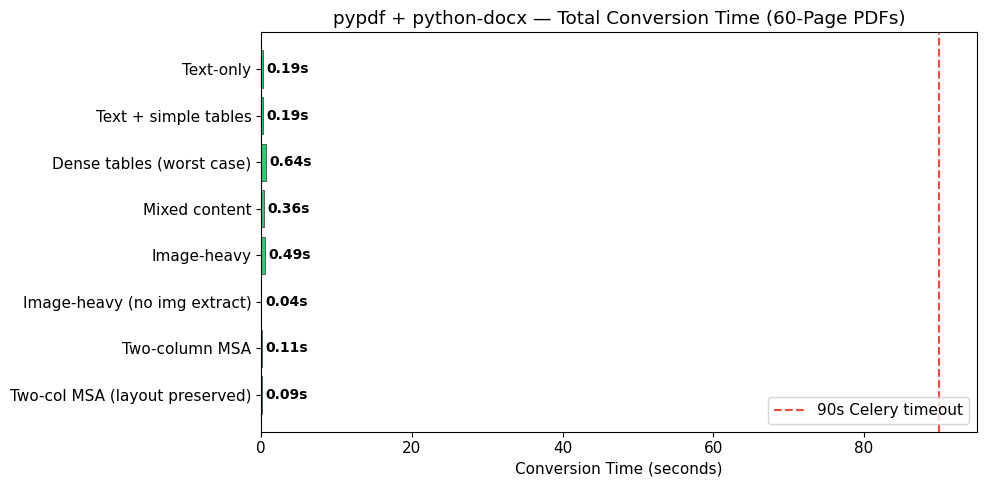

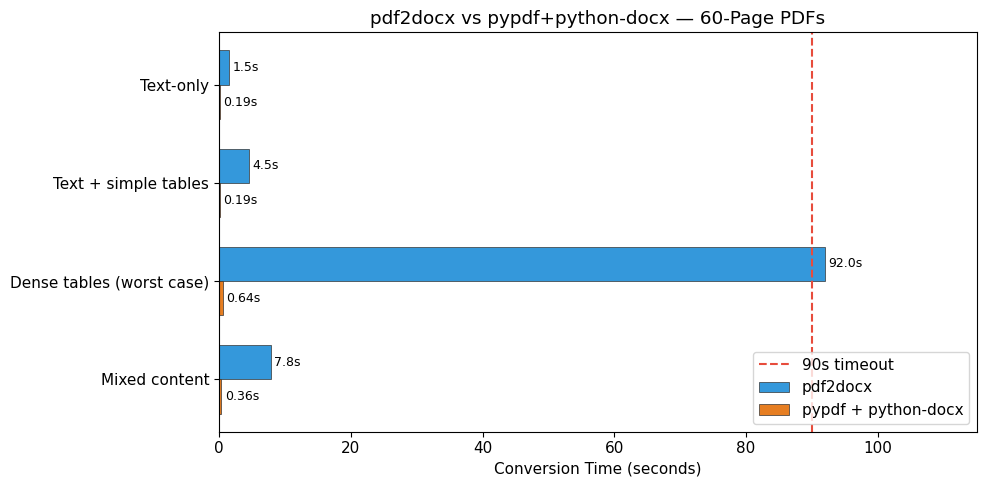


Charts saved to /tmp/pypdf_docx_bench/


In [12]:
try:
    import matplotlib
    import matplotlib.pyplot as plt
    HAS_MPL = True
except ImportError:
    HAS_MPL = False
    print("matplotlib not installed — skipping charts.")

if HAS_MPL:
    matplotlib.rcParams.update({"font.size": 11})

    # --- Chart 1: pypdf+docx results ---
    scenarios = [r["scenario"] for r in results]
    times = [r["total_s"] for r in results]
    colors = ["#2ecc71" if t < 60 else ("#f39c12" if t < 90 else "#e74c3c") for t in times]

    fig, ax1 = plt.subplots(1, 1, figsize=(10, 5))
    bars = ax1.barh(scenarios, times, color=colors, edgecolor="#333", linewidth=0.5)
    ax1.axvline(x=90, color="#e74c3c", linestyle="--", linewidth=1.5, label="90s Celery timeout")
    ax1.set_xlabel("Conversion Time (seconds)")
    ax1.set_title(f"pypdf + python-docx — Total Conversion Time ({PAGES}-Page PDFs)")
    ax1.legend(loc="lower right")
    for bar, t in zip(bars, times):
        ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2, f"{t:.2f}s",
                 va="center", fontsize=10, fontweight="bold")
    ax1.set_xlim(0, max(max(times) * 1.3, 95))
    ax1.invert_yaxis()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "pypdf_docx_results.png"), dpi=150, bbox_inches="tight")
    plt.show()

    # --- Chart 2: Head-to-head comparison ---
    comparable = [r for r in results if r["scenario"] in pdf2docx_results]
    if comparable:
        fig, ax2 = plt.subplots(1, 1, figsize=(10, 5))
        names = [r["scenario"] for r in comparable]
        pypdf_times = [r["total_s"] for r in comparable]
        p2d_times = [pdf2docx_results[r["scenario"]]["total_s"] for r in comparable]
        
        x = range(len(names))
        width = 0.35
        bars1 = ax2.barh([i - width/2 for i in x], p2d_times, height=width,
                         color="#3498db", edgecolor="#333", linewidth=0.5, label="pdf2docx")
        bars2 = ax2.barh([i + width/2 for i in x], pypdf_times, height=width,
                         color="#e67e22", edgecolor="#333", linewidth=0.5, label="pypdf + python-docx")
        
        ax2.axvline(x=90, color="#e74c3c", linestyle="--", linewidth=1.5, label="90s timeout")
        ax2.set_yticks(list(x))
        ax2.set_yticklabels(names)
        ax2.set_xlabel("Conversion Time (seconds)")
        ax2.set_title(f"pdf2docx vs pypdf+python-docx — {PAGES}-Page PDFs")
        ax2.legend(loc="lower right")
        
        for bar, t in zip(bars1, p2d_times):
            ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2, f"{t:.1f}s",
                     va="center", fontsize=9)
        for bar, t in zip(bars2, pypdf_times):
            ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2, f"{t:.2f}s",
                     va="center", fontsize=9)
        
        ax2.set_xlim(0, max(max(p2d_times), max(pypdf_times)) * 1.25)
        ax2.invert_yaxis()
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, "comparison_chart.png"), dpi=150, bbox_inches="tight")
        plt.show()
        print(f"\nCharts saved to {OUTPUT_DIR}/")

---
## Tradeoff Analysis

### Speed vs Fidelity

| Dimension | pdf2docx | pypdf + python-docx |
|-----------|----------|---------------------|
| **Table detection** | Yes — reconstructs table structure | No — tables become flat text |
| **Layout preservation** | Good — maintains spatial layout | None — reading-order text only |
| **Font/style mapping** | Partial — maps fonts and sizes | None — default DOCX styles |
| **Image handling** | Preserves position and size | Extracts images, appends after text |
| **Performance** | Fast for text, slow for tables (O(n^2)) | Consistently fast (no table detection) |
| **Timeout risk** | Dense tables can exceed 90s | Unlikely to exceed 90s |
| **Dependencies** | PyMuPDF (C extension) | Pure Python (no C deps) |
| **Maintenance** | ArtifexSoftware — less active | py-pdf org — actively maintained |

### When to use which

- **pypdf + python-docx:** When speed matters more than fidelity. Good for text-heavy documents where you just need the content in DOCX format. No timeout risk. Pure Python = easy deployment.
- **pdf2docx:** When layout fidelity matters. Better for documents with tables, complex formatting. But carries timeout risk for dense table documents.

### Hybrid approach

A potential strategy: use PyMuPDF to pre-screen documents, count tables/drawings per page, and route:
- Simple documents → pypdf + python-docx (fast, no timeout risk)
- Complex documents → pdf2docx with timeout wrapper
- Table-heavy documents → pdf2docx with chunked conversion (`start`/`end` params)

---